---
jupyter: python3
---


# Exercise 1: List patients using the get method from requests_fhir

The file request_fhir.py should be in the same folder as this markdown file.
From the exercise:

The request_fhir.py is a simple mock server which is built upon the data used throughout this course. This exercise is about trying to interact with data on a fhir database through restAPI calls where the usage of a base url is central. 

To understand the structure 

In [8]:
import json
import request_fhir as requests
import pandas as pd
import matplotlib.pyplot as plt

BASE_URL = 'https://test/fhir'
json_headers = {'content-type': 'application/json', 'accept': 'text/plain'}

Check if it works, the output should be related to error 501 (didn't actually ask for any information)

In [9]:
print(requests.get(BASE_URL))

<Response [501]>


Retrieving the full patient list:

In [10]:
BASE_URL = 'https://test/fhir/'
json_headers = {'Content-type': 'application/json',
'Accept': 'text/plain'}

# --- EXERCISE 1: LIST PATIENTS (Your working solution) ---
print("--- Exercise 1: List of Patients ---")
patients_url = f'{BASE_URL}Patient' # Using f-string without the extra slash
response = requests.get(patients_url)

# The response content is correctly accessed via ._content
bundle = json.loads(response._content)
patients_df = pd.DataFrame(columns=['id', 'sex', 'd.birth'])

if bundle['resourceType'] == 'Bundle' and bundle['type'] == 'searchset':
    print(f"Found {len(bundle.get('entry', []))} patients:")
    for entry in bundle.get('entry', []):
        patient = entry.get('resource')
        if patient and patient['resourceType'] == 'Patient':
            patient_id = patient.get('id', 'N/A')
            sex = patient.get('gender', 'N/A')
            birthdate = patient.get('birthDate', 'N/A')
            
            new_row = pd.DataFrame([{'id': patient_id, 'sex': sex, 'd.birth': birthdate}])
            patients_df = pd.concat([patients_df, new_row], ignore_index=True)

print(patients_df)

--- Exercise 1: List of Patients ---
Found 742 patients:
       id     sex     d.birth
0       2  female  1941-07-14
1       3    male  1931-10-02
2       4    male  1944-11-22
3       5  female  1939-04-13
4       6    male  1962-04-18
..    ...     ...         ...
737  1592  female  1942-04-06
738  1593    male  1950-02-08
739  1594  female  1928-12-07
740  1595    male  1942-08-27
741  1596  female  1936-04-05

[742 rows x 3 columns]


# Exercise 2: Look at the snomed.csv file inside the data folder to see which code to use to access the data

In [11]:
snomed_df = pd.read_csv('data/snomed.csv')
cholesterol_label = 'ldl'
cholesterol_info = snomed_df[snomed_df['label'] == cholesterol_label]
cholesterol_code = cholesterol_info['code'].iloc[0]
cholesterol_code

166833005

# Exercise 3: Get measurements of cholesterol for a patient

In [12]:
snomed = pd.read_csv("data/snomed.csv")

A plot for Patient 2's cholesterol has been generated.


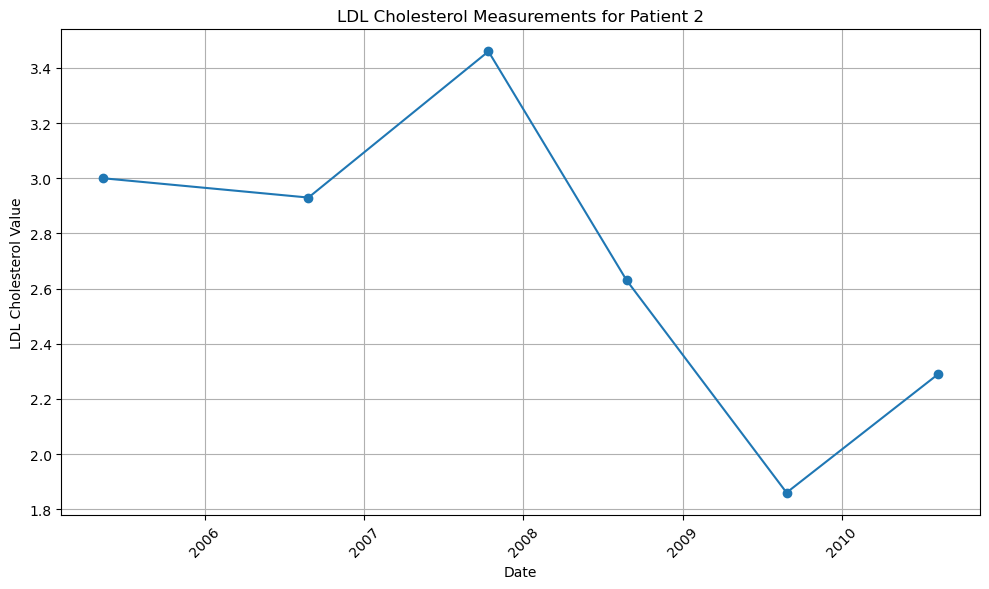

In [13]:
patient_id = patients_df['id'].iloc[0]

# The URL for observations is constructed
observation_url = BASE_URL + f'Observation?patient={patient_id}&code={cholesterol_code}'
obs_response = requests.get(observation_url)

# *** THIS IS THE KEY CHANGE FOR EXERCISE 3 ***
# The response is correctly parsed using ._content
obs_data = json.loads(obs_response._content)

measurements = []
for entry in obs_data.get('entry', []):
    resource = entry.get('resource', {})
    if resource.get('resourceType') == 'Observation':
        date = resource.get('effectiveDateTime')
        value = resource.get('valueQuantity', {}).get('value')
        if date and value:
            measurements.append({'date': date, 'value': float(value)})
measurements_df = pd.DataFrame(measurements)
measurements_df['date'] = pd.to_datetime(measurements_df['date'])
measurements_df = measurements_df.sort_values(by='date')

plt.figure(figsize=(10, 6))
plt.plot(measurements_df['date'], measurements_df['value'], marker='o', linestyle='-')
plt.title(f'LDL Cholesterol Measurements for Patient {patient_id}')
plt.xlabel('Date')
plt.ylabel('LDL Cholesterol Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
print(f"A plot for Patient {patient_id}'s cholesterol has been generated.")
plt.show()

## Python Bonus Exercise

A bonus exercise has been created exclusively for Python users, which involves working with FHIR (Fast Healthcare Interoperability Resources).

This exercise is completed when the following server responses have been achieved:

INFO: 127.0.0.1:60160 - "POST /Patient HTTP/1.1" 200 OK

INFO: 127.0.0.1:60161 - "GET /Patient/7ce15ccd-47d5-4808-bbd8-3eef4c7738b2 HTTP/1.1" 200 OK

### Task 4.1: Creating a Patient Resource
A patient resource must be created that includes a human name and a contact point. The fhir.resources package in Python will be needed for this task. This package aligns directly with the FHIR documentation and resource content, as can be seen at https://hl7.org/fhir/patient.html.

### Task 4.2: Interacting with a FHIR Database
After a patient has been successfully created, an interaction with a FHIR database must be attempted using a URL for a database on a server. A mock server can be run on a local machine for this task. The exercise files directory must be found, and the following command must be executed:

$ python mock_fhir_server.py

Through the use of this mock server, interaction with a server is made possible.

In [14]:
# 4.1
from fhir.resources.patient import Patient
from fhir.resources.humanname import HumanName
from fhir.resources.contactpoint import ContactPoint

import requests

patient = Patient()
name = HumanName()
name.given = ["Henning"]
name.family = "Hansen"
patient.name = [name]
contact_point = ContactPoint()
contact_point.system = "email"
contact_point.value = "henning@mail.com"
patient.telecom = [contact_point]

patient_dict = patient.model_dump(by_alias=True, exclude_none=True)

print("Patient object to be posted:", patient_dict)

Patient object to be posted: {'resourceType': 'Patient', 'name': [{'family': 'Hansen', 'given': ['Henning']}], 'telecom': [{'system': 'email', 'value': 'henning@mail.com'}]}


In [15]:
# Go to the terminal of the IDE, execute the command: "python mock_fhir_server.py" 

In [16]:
# 4.2
base_url = "http://127.0.0.1:8000"
response = requests.post(base_url + "/Patient", json=patient_dict)


response.raise_for_status()

print("\nServer response content:", response.content)

response_patient = Patient.model_validate_json(response.content)

print("\nID assigned by the server:", response_patient.id)

get_response = requests.get(base_url + "/Patient/" + response_patient.id)

get_response.raise_for_status()

print("\nGET request response content:", get_response.content)

# Check the terminal where the mock server was executed to see if it respond


Server response content: b'{"resourceType":"Patient","id":"2d33898a-591f-46b6-9e9c-34710ba68726","meta":null,"implicitRules":null,"language":null,"text":null,"contained":null,"extension":null,"modifierExtension":null,"identifier":null,"active":null,"name":[{"id":null,"extension":null,"use":null,"text":null,"family":"Hansen","given":["Henning"],"prefix":null,"suffix":null,"period":null}],"telecom":[{"id":null,"extension":null,"system":"email","value":"henning@mail.com","use":null,"rank":null,"period":null}],"gender":null,"birthDate":null,"deceasedBoolean":null,"deceasedDateTime":null,"address":null,"maritalStatus":null,"multipleBirthBoolean":null,"multipleBirthInteger":null,"photo":null,"contact":null,"communication":null,"generalPractitioner":null,"managingOrganization":null,"link":null}'

ID assigned by the server: 2d33898a-591f-46b6-9e9c-34710ba68726

GET request response content: b'{"resourceType":"Patient","id":"2d33898a-591f-46b6-9e9c-34710ba68726","meta":null,"implicitRules":nul